## 0. Libraries

In [25]:
suppressPackageStartupMessages({
  library(deSolve)   # ODE solver
  library(numDeriv)  # numerical Jacobian (jacobian)
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(LoopDetectR)
})

## 1. Configuration

In [24]:
colors <- c("#EE7733", "#0077BB", "#33BBEE", "#EE3377", "#CC3311", "#009988", "#BBBBBB")

## 2. Main reproduction

#### **Example 3: Model of complex formation with activation-deactivation cycle**

The model of complex formation with activation-deactivation cycle has also been investigated in [4]. It is composed of the basic model of complex formation in that A
and B bind to form complex AB as described in section 1.2, together with an activation and deactivation of one of the complex-forming species, B and B∗. In addition
to the two reactions of complex formation and complex decomposition, the activating
reaction and the deactivation reaction are modelled using Michaelis-Menten reaction
kinetics. Thereby, the activation of B to B∗
is in addition stimulus-dependent (the
stimulus is modelled as a parameter, kn3), while the deactivation of B∗
to B depends
linearly on species A. The model contains four species, A, B, AB, B∗
, four rate coefficients, k1 . . . , k4, two activation constants, kn1, kn2, and a stimulus parameter, kn3.

$$
\begin{aligned}
\frac{dA}{dt} &= -k_1\,A\,B + k_2\,AB ,\\[6pt]
\frac{dB}{dt} &= -k_1\,A\,B + k_2\,AB + k_3\,A\,\frac{B^*}{B^* + kn_1} - k_4\,kn_3\,\frac{B}{B + kn_2} ,\\[6pt]
\frac{d(AB)}{dt} &= k_1\,A\,B - k_2\,AB ,\\[6pt]
\frac{dB^*}{dt} &= -k_3\,A\,\frac{B^*}{B^* + kn_1} + k_4\,kn_3\,\frac{B}{B + kn_2} .
\end{aligned}
$$

We employed the following parameter set for the analyses: k1 = 0.021458, k2 =
0.000227335, k3 = 663.297, k4 = 0.000139797, kn1 = 55.5913, kn2 = 10.2194, and
values for the stimulus of kn3 = 1 (unstimulated) or kn3 = 20 (stimulated). The initial
conditions were set as A = 5, B = 300, AB = 0.0001, B∗ = 0.01.



In [ ]:
#### 

In [3]:
model_complex_formation_act_deact_cycle <- function(t, y, params) {
  A      <- y[1]
  B      <- y[2]
  AB     <- y[3]
  B_star <- y[4]

  k1  <- params[1]
  k2  <- params[2]
  k3  <- params[3]
  k4  <- params[4]
  kn1 <- params[5]
  kn2 <- params[6]
  kn3 <- params[7]

  dAdt      <- -k1 * A * B + k2 * AB
  dBdt      <- -k1 * A * B + k2 * AB + k3 * A * (B_star / (B_star + kn1)) - k4 * kn3 * (B / (B + kn2))
  dABdt     <-  k1 * A * B - k2 * AB
  dB_stardt <- -k3 * A * (B_star / (B_star + kn1)) + k4 * kn3 * (B / (B + kn2))

  list(c(dAdt, dBdt, dABdt, dB_stardt))
}

solve_complex_formation_act_deact_cycle <- function(initial_conditions, time_points, params) {
  y0 <- c(A = initial_conditions[1],
          B = initial_conditions[2],
          AB = initial_conditions[3],
          B_star = initial_conditions[4])

  out <- deSolve::ode(
    y = y0,
    times = time_points,
    func = model_complex_formation_act_deact_cycle,
    parms = params,
    method = "lsoda"
  )
  out <- as.data.frame(out)
  out
}

In [ ]:
res_tab <- find_loops_vset(func_POSm4,vset=list(s_star),t=1,klin=klin,
                           knonlin=knonlin,max_num_loops=10)

In [ ]:
# Parameters from supplementary material
initial_conditions_act_deact <- c(5, 300, 0.0001, 0.01)

k1 <- 0.021458
k2 <- 0.000227335
k3 <- 663.297
k4 <- 0.000139797
kn1 <- 55.5913
kn2 <- 10.2194
kn3_unstimulated <- 1.0
kn3_stimulated   <- 20.0

params_act_deact_unstimulated <- c(k1, k2, k3, k4, kn1, kn2, kn3_unstimulated)
params_act_deact_stimulated   <- c(k1, k2, k3, k4, kn1, kn2, kn3_stimulated)

In [5]:
time_points_act_deact <- seq(0, 5000, length.out = 1001)
sol_act_deact <- solve_complex_formation_act_deact_cycle(
  initial_conditions = initial_conditions_act_deact,
  time_points = time_points_act_deact,
  params = params_act_deact_unstimulated
)

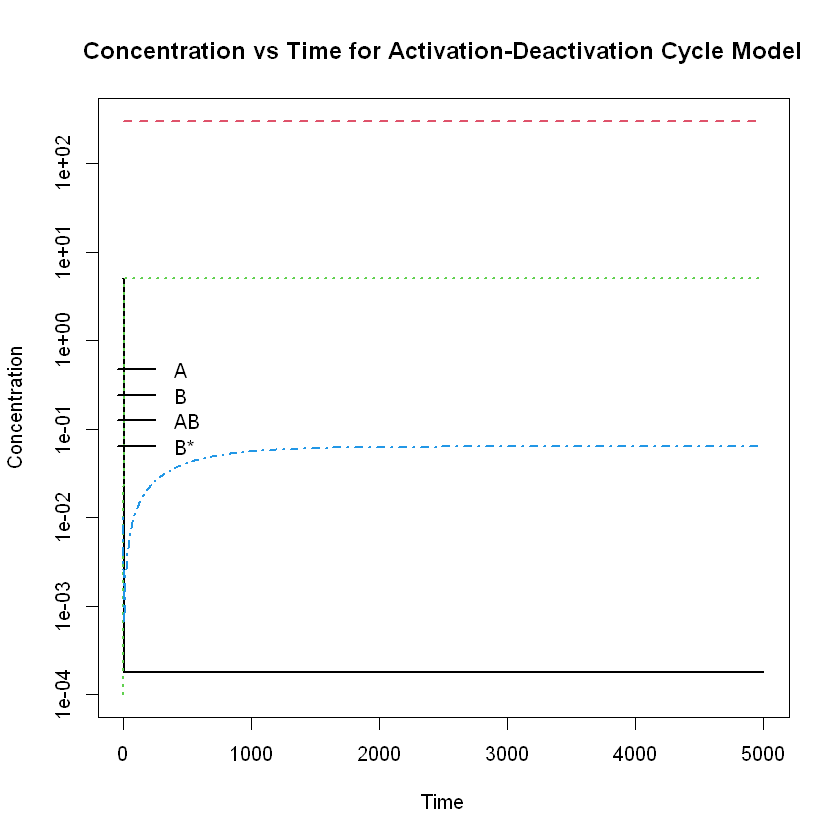

In [6]:
matplot(
  sol_act_deact$time,
  sol_act_deact[, c("A", "B", "AB", "B_star")],
  type = "l", lwd = 2, log = "y",
  xlab = "Time", ylab = "Concentration",
  main = "Concentration vs Time for Activation-Deactivation Cycle Model"
)
legend("left", legend = c("A", "B", "AB", "B*"), lty = 1, lwd = 2, bty = "n")

In [7]:
time_1 <- seq(-1000, 0, length.out = 500)
time_2 <- seq(0, 2000, length.out = 1000)

# Continue from stabilized final state
y_stable <- as.numeric(sol_act_deact[nrow(sol_act_deact), c("A", "B", "AB", "B_star")])

sol_unstimulated <- solve_complex_formation_act_deact_cycle(
  initial_conditions = y_stable,
  time_points = time_1,
  params = params_act_deact_unstimulated
)

y_at_0 <- as.numeric(sol_unstimulated[nrow(sol_unstimulated), c("A", "B", "AB", "B_star")])

sol_stimulated <- solve_complex_formation_act_deact_cycle(
  initial_conditions = y_at_0,
  time_points = time_2,
  params = params_act_deact_stimulated
)

# Combine full trajectory
time_full <- c(time_1, time_2)
sol_full <- bind_rows(sol_unstimulated, sol_stimulated) %>%
  select(time, A, B, AB, B_star)

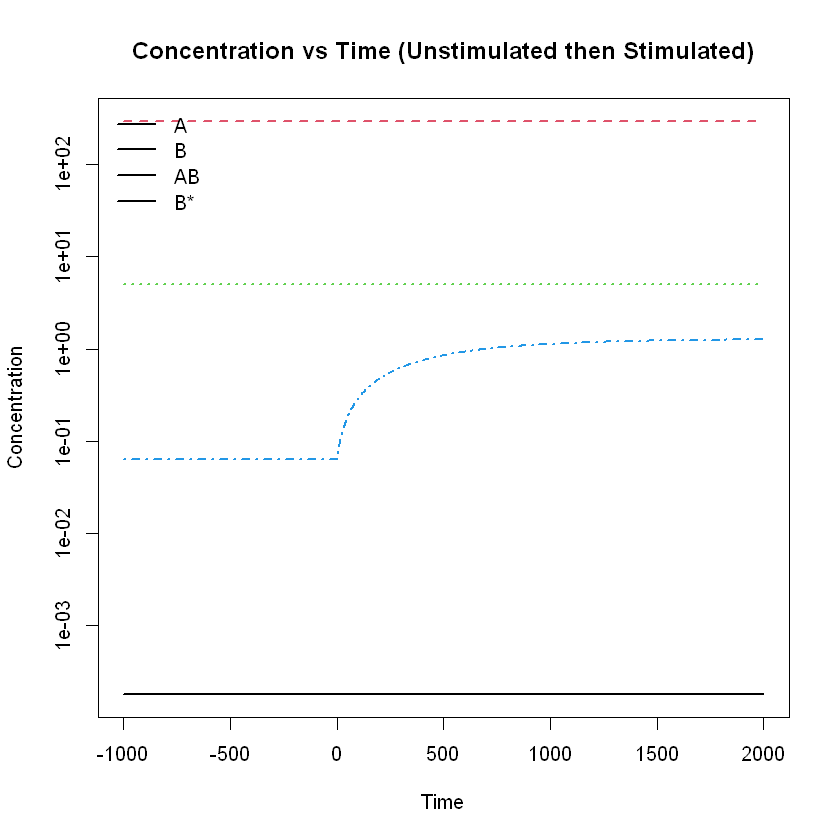

In [8]:
matplot(
  sol_full$time,
  sol_full[, c("A", "B", "AB", "B_star")],
  type = "l", lwd = 2, log = "y",
  xlab = "Time", ylab = "Concentration",
  main = "Concentration vs Time (Unstimulated then Stimulated)"
)
legend("topleft", legend = c("A", "B", "AB", "B*"), lty = 1, lwd = 2, bty = "n")

In [9]:
# Numerical Jacobian + signed Jacobian
vf <- function(y, params) {
  # deSolve model returns list(c(...)); unwrap
  model_complex_formation_act_deact_cycle(t = 0, y = y, params = params)[[1]]
}

# Evaluate Jacobian at the stabilized endpoint (same as Python: sol_act_deact.y[:, -1])
y_eval_un <- as.numeric(sol_act_deact[nrow(sol_act_deact), c("A", "B", "AB", "B_star")])
J_un <- numDeriv::jacobian(func = function(x) vf(x, params_act_deact_unstimulated), x = y_eval_un)
Jsign_un <- sign(J_un)

# Evaluate Jacobian at end of sol_unstimulated (t=0-) for stimulated params (Python used sol_unstimulated.y[:, -1])
y_eval_st <- as.numeric(sol_unstimulated[nrow(sol_unstimulated), c("A", "B", "AB", "B_star")])
J_st <- numDeriv::jacobian(func = function(x) vf(x, params_act_deact_stimulated), x = y_eval_st)
Jsign_st <- sign(J_st)

cat("Unstimulated conditions:\n")
cat("Jacobian matrix:\n"); print(J_un)
cat("Signed Jacobian matrix:\n"); print(Jsign_un)

Unstimulated conditions:
Jacobian matrix:
           [,1]          [,2]         [,3]         [,4]
[1,] -6.3289739 -3.853766e-06  0.000227335  0.000000000
[2,] -5.5766599 -3.869107e-06  0.000227335  0.002138019
[3,]  6.3289739  3.853766e-06 -0.000227335  0.000000000
[4,] -0.7523141  1.534086e-08  0.000000000 -0.002138019
Signed Jacobian matrix:
     [,1] [,2] [,3] [,4]
[1,]   -1   -1    1    0
[2,]   -1   -1    1    1
[3,]    1    1   -1    0
[4,]   -1    1    0   -1


In [11]:
find_loops_signed <- function(Jsign, max_len = 4) {
  n <- nrow(Jsign)
  nodes <- 0:(n - 1)

  has_edge <- function(i, j) Jsign[i + 1, j + 1] != 0
  edge_sign <- function(i, j) Jsign[i + 1, j + 1]

  loops <- list()

  # length 1: self loops
  for (i in nodes) {
    if (has_edge(i, i)) {
      loops <- append(loops, list(list(loop = c(i, i), length = 1L, sign = as.integer(edge_sign(i, i)))))
    }
  }

  # length 2..max_len
  if (max_len >= 2) {
    # length 2: i -> j -> i, i!=j
    for (i in nodes) for (j in nodes) if (i != j) {
      if (has_edge(i, j) && has_edge(j, i)) {
        s <- edge_sign(i, j) * edge_sign(j, i)
        loops <- append(loops, list(list(loop = c(i, j, i), length = 2L, sign = as.integer(s))))
      }
    }
  }

  if (max_len >= 3) {
    # length 3: i -> j -> k -> i, all distinct
    for (i in nodes) for (j in nodes) for (k in nodes) {
      if (length(unique(c(i, j, k))) == 3) {
        if (has_edge(i, j) && has_edge(j, k) && has_edge(k, i)) {
          s <- edge_sign(i, j) * edge_sign(j, k) * edge_sign(k, i)
          loops <- append(loops, list(list(loop = c(i, j, k, i), length = 3L, sign = as.integer(s))))
        }
      }
    }
  }

  if (max_len >= 4) {
    # length 4: i -> j -> k -> l -> i, all distinct
    for (i in nodes) for (j in nodes) for (k in nodes) for (l in nodes) {
      if (length(unique(c(i, j, k, l))) == 4) {
        if (has_edge(i, j) && has_edge(j, k) && has_edge(k, l) && has_edge(l, i)) {
          s <- edge_sign(i, j) * edge_sign(j, k) * edge_sign(k, l) * edge_sign(l, i)
          loops <- append(loops, list(list(loop = c(i, j, k, l, i), length = 4L, sign = as.integer(s))))
        }
      }
    }
  }

  # Deduplicate cycles up to rotation/reversal can be non-trivial.
  # For n=4 and this example, we keep as-is and then distinct by exact sequence.
  df <- tibble(
    loop = map(loops, "loop"),
    length = map_int(loops, "length"),
    sign = map_int(loops, "sign")
  ) %>%
    distinct(loop, length, sign) %>%
    arrange(length, loop)

  df
}

In [12]:
loop_summary_table <- function(loop_df) {
  loop_df %>%
    mutate(length = as.integer(length),
           pos = sign > 0,
           neg = sign < 0) %>%
    group_by(length) %>%
    summarise(
      total = n(),
      pos = sum(pos),
      neg = sum(neg),
      .groups = "drop"
    ) %>%
    arrange(length)
}

In [23]:
cat("\nUnstimulated conditions:\n")
res_tab_complex_loop_rep <- find_loops_signed(Jsign_un, max_len = 4)
print(res_tab_complex_loop_rep)

cat("\nLoop summary for unstimulated conditions:\n")
print(loop_summary_table(res_tab_complex_loop_rep))


Unstimulated conditions:


# A tibble: 25 × 3
   loop      length  sign
   <list>     <int> <int>
 1 <int [2]>      1    -1
 2 <int [2]>      1    -1
 3 <int [2]>      1    -1
 4 <int [2]>      1    -1
 5 <int [3]>      2     1
 6 <int [3]>      2     1
 7 <int [3]>      2     1
 8 <int [3]>      2     1
 9 <int [3]>      2     1
10 <int [3]>      2     1
# ℹ 15 more rows

Loop summary for unstimulated conditions:
# A tibble: 4 × 4
  length total   pos   neg
   <int> <int> <int> <int>
1      1     4     0     4
2      2     8     8     0
3      3     9     3     6
4      4     4     0     4


#### **2.7. Search time where signed Jacobian structure changes**

In [14]:
Jsign_ref_un <- Jsign_un
Jsign_ref_st <- Jsign_st

t_change <- NA_real_
J_change <- NULL
Jsign_change <- NULL
summary_change <- NULL

# Use a modest stride to avoid heavy computation; set stride=1 for exact match (slower).
stride <- 1L

for (idx in seq(1, nrow(sol_full), by = stride)) {
  t_now <- sol_full$time[idx]
  y_now <- as.numeric(sol_full[idx, c("A", "B", "AB", "B_star")])

  params_now <- if (t_now < 0) params_act_deact_unstimulated else params_act_deact_stimulated
  J_now <- numDeriv::jacobian(func = function(x) vf(x, params_now), x = y_now)
  Jsign_now <- sign(J_now)

  Jsign_ref <- if (t_now < 0) Jsign_ref_un else Jsign_ref_st

  if (!isTRUE(all.equal(Jsign_now, Jsign_ref))) {
    t_change <- t_now
    J_change <- J_now
    Jsign_change <- Jsign_now
    summary_change <- loop_summary_table(find_loops_signed(Jsign_now, max_len = 4))
    break
  }
}

if (!is.na(t_change)) {
  cat(sprintf("\nAt time %.2f after the stimulus, the signed Jacobian structure changes.\n", t_change))
  cat("Jacobian matrix at this time:\n"); print(J_change)
  cat("Signed Jacobian matrix at this time:\n"); print(Jsign_change)
  cat("Loop summary at this time:\n"); print(summary_change)
} else {
  cat("\nNo signed Jacobian structure change detected on the scanned grid.\n")
}



At time 234.23 after the stimulus, the signed Jacobian structure changes.
Jacobian matrix at this time:
            [,1]          [,2]         [,3]         [,4]
[1,] -6.31881288 -3.859960e-06  0.000227335  0.000000000
[2,]  0.02316377 -4.167731e-06  0.000227335  0.002105474
[3,]  6.31881288  3.859960e-06 -0.000227335  0.000000000
[4,] -6.34197665  3.077716e-07  0.000000000 -0.002105474
Signed Jacobian matrix at this time:
     [,1] [,2] [,3] [,4]
[1,]   -1   -1    1    0
[2,]    1   -1    1    1
[3,]    1    1   -1    0
[4,]   -1    1    0   -1
Loop summary at this time:
# A tibble: 4 × 4
  length total   pos   neg
   <int> <int> <int> <int>
1      1     4     0     4
2      2     8     6     2
3      3     9     6     3
4      4     4     0     4


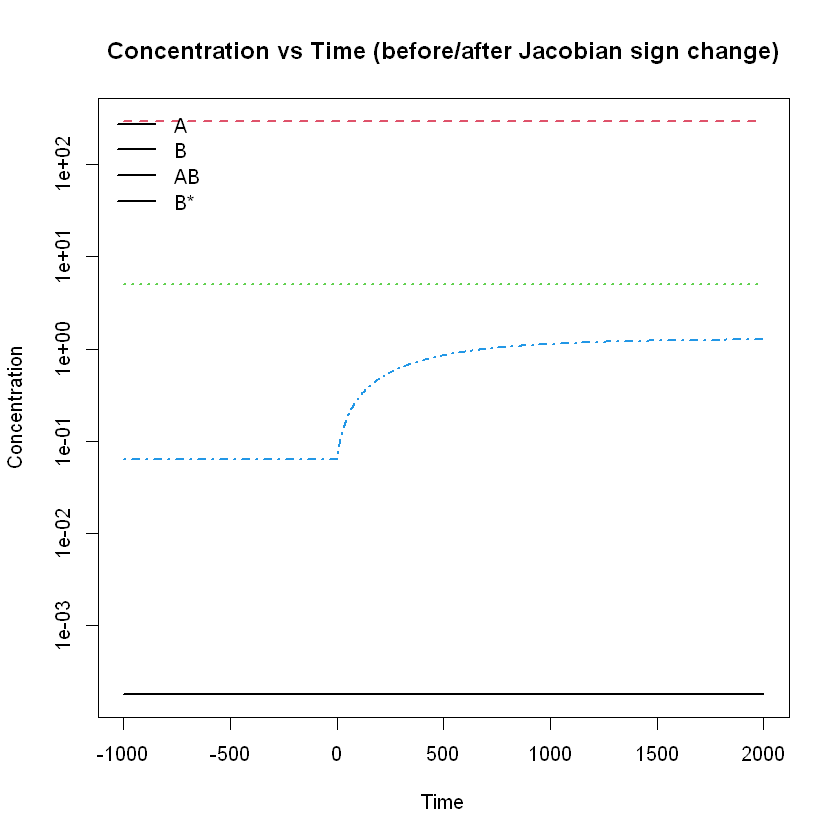

In [15]:
if (!is.na(t_change)) {
  matplot(
    sol_full$time,
    sol_full[, c("A", "B", "AB", "B_star")],
    type = "l", lwd = 2, log = "y",
    xlab = "Time", ylab = "Concentration",
    main = "Concentration vs Time (before/after Jacobian sign change)"
  )
  usr <- par("usr")
  rect(xleft = min(sol_full$time), ybottom = usr[3], xright = t_change, ytop = usr[4],
       border = NA, col = rgb(0, 0, 1, alpha = 0.1))
  rect(xleft = t_change, ybottom = usr[3], xright = max(sol_full$time), ytop = usr[4],
       border = NA, col = rgb(1, 0, 0, alpha = 0.1))
  matlines(sol_full$time, sol_full[, c("A", "B", "AB", "B_star")], lwd = 2)
  legend("topleft", legend = c("A", "B", "AB", "B*"), lty = 1, lwd = 2, bty = "n")
}

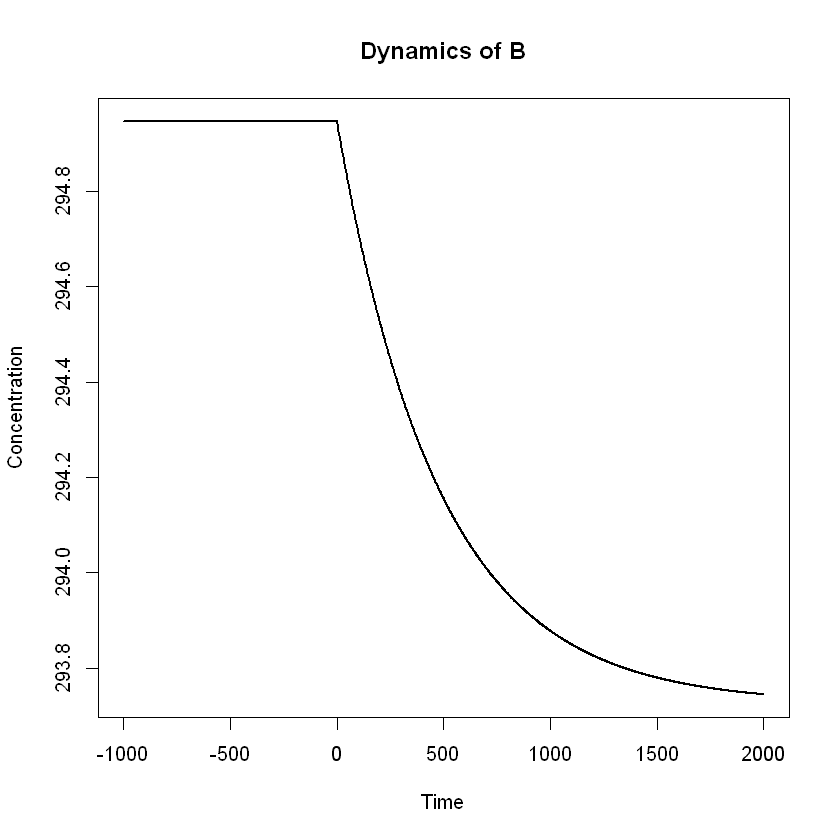

In [16]:
plot(sol_full$time, sol_full$B, type = "l", lwd = 2,
     xlim = c(-999, 2000),
     xlab = "Time", ylab = "Concentration",
     main = "Dynamics of B")
axis(1, at = c(0, 2000))

## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [17]:
id_to_subject <- c("A", "B", "AB", "B*")
names(id_to_subject) <- as.character(0:3)

df_loops <- res_tab_complex_loop_rep %>%
  mutate(
    loop_subject = map(loop, ~ unname(id_to_subject[as.character(.x)]))
  ) %>%
  arrange(length, loop)

print(df_loops)

# A tibble: 25 × 4
   loop      length  sign loop_subject
   <list>     <int> <int> <list>      
 1 <int [2]>      1    -1 <chr [2]>   
 2 <int [2]>      1    -1 <chr [2]>   
 3 <int [2]>      1    -1 <chr [2]>   
 4 <int [2]>      1    -1 <chr [2]>   
 5 <int [3]>      2     1 <chr [3]>   
 6 <int [3]>      2     1 <chr [3]>   
 7 <int [3]>      2     1 <chr [3]>   
 8 <int [3]>      2     1 <chr [3]>   
 9 <int [3]>      2     1 <chr [3]>   
10 <int [3]>      2     1 <chr [3]>   
# ℹ 15 more rows
